# Dataset A

In [ ]:
from torchvision import datasets , transforms
from torch.utils.data import DataLoader, Dataset,Subset
import numpy as np

CIFAR10_MEAN = (0.4914 , 0.4822 , 0.4465)
CIFAR10_STD = (0.2470 , 0.2435 , 0.2616)

class RemapCifar(Dataset):
  def __init__(self, dataset, class_2):
    self.dataset = dataset
    self.class_2 = class_2
  def __len__(self):
    return len(self.dataset)
  def __getitem__(self, idx):
    image, label = self.dataset[idx]
    label = float(label == self.class_2)
    return image, label



def pick_classes(dataset,class_1, class_2):
  # keeps only the classes that were chosen
  labels = np.array(dataset.targets)
  target =[class_1,class_2]
  indexes =  np.where(np.isin(labels,target))[0]
  dataset = Subset(dataset,indexes)
  return RemapCifar(dataset,class_2)


Class1,Class2 = 3, 8

# dataset A transforms
train_transform = transforms.Compose([
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize( CIFAR10_MEAN , CIFAR10_STD ) ,
])

# dataset test A transforms
test_transform = transforms.Compose([
transforms.ToTensor() ,
transforms.Normalize( CIFAR10_MEAN , CIFAR10_STD ) ,
])

# Dataset A
train_set = datasets.CIFAR10( "./data" , train = True , download = True ,
transform = train_transform )
train_set = pick_classes(train_set,Class1,Class2)

test_set = datasets.CIFAR10( "./data" , train = False , download = True ,
transform = test_transform )
test_set = pick_classes(test_set,Class1,Class2)

train_loader = DataLoader( train_set , batch_size =64 , shuffle = True )
test_loader = DataLoader( test_set , batch_size =64 , shuffle = False )



# Dataset B

In [ ]:
# dataset B transforms
train_transform_gray = transforms.Compose([
    transforms.Grayscale( num_output_channels =3) ,
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  transforms.Normalize( CIFAR10_MEAN , CIFAR10_STD ),
])


# dataset  test B transforms
test_transform_gray = transforms.Compose([
  transforms.Grayscale( num_output_channels =3) ,
  transforms.ToTensor() ,
  transforms.Normalize( CIFAR10_MEAN , CIFAR10_STD ) ,
])


# grayscale Data Set B
train_set_grayscale = datasets.CIFAR10( "./data" , train = True , download = True ,
transform = train_transform_gray )
train_set_grayscale = pick_classes(train_set_grayscale,Class1,Class2)

test_set_grayscale = datasets.CIFAR10( "./data" , train = False , download = True ,
transform = test_transform_gray )
test_set_grayscale = pick_classes(test_set_grayscale,Class1,Class2)


train_loader_grayscale = DataLoader( train_set_grayscale , batch_size =64 , shuffle = True )
test_loader_grayscale = DataLoader( test_set_grayscale , batch_size =64 , shuffle = False )

# Part A

In [ ]:
# the model
import torch
import torch.nn as nn
import torch.nn.functional as F

class CoolCNN(nn.Module):
  def __init__(self, num_classes=2, dropout_rate=0.0):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32,64, 3, padding=1)
    self.conv3 = nn.Conv2d(64,128,3, padding=1)
    self.pool = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(128*8*8,128)
    self.fc2 = nn.Linear(128,num_classes)
    self.drop = nn.Dropout(dropout_rate)

  def forward(self,x):

    x = F.relu(self.conv1(x))

    x = self.pool(F.relu(self.conv2(x)))

    x = self.pool(F.relu(self.conv3(x)))
    x = torch.flatten(x,1)
    x = self.drop(F.relu(self.fc1(x)))

    return self.fc2(x)


In [ ]:
def train(model, train_loader, test_loader, num_epochs, learning_rate):

  optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
  loss_function = nn.CrossEntropyLoss()

  train_accs = []
  train_losses =[]
  test_accs = []
  test_losses = []
  for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for X,y in train_loader:
      y = y.long()
      # zero gradients
      optimizer.zero_grad()
      # prediction
      y_pred = model(X)
      loss = loss_function(y_pred,y)
      # compute gradients
      loss.backward()
      # update weights
      optimizer.step()

      train_loss += loss.item()
      train_total += y.size(0)
      # num of correct labels
      train_correct += (y_pred.argmax(dim=1) == y).sum().item()

    # compute metrics
    train_accs.append(train_correct/train_total)
    train_losses.append(train_loss/len(train_loader))
    print(f"Epoch: {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_correct/train_total}")


    model.eval()
    with torch.no_grad():
      test_loss = 0.0
      test_correct = 0
      test_total = 0
      for X,y in test_loader:
        y = y.long()
        y_pred = model(X)
        loss = loss_function(y_pred,y)

        test_loss += loss.item()
        test_total += y.size(0)
        test_correct += (y_pred.argmax(dim=1) == y).sum().item()

      test_accs.append(test_correct/test_total)
      test_losses.append(test_loss/len(test_loader))
    print(f"Epoch: {epoch+1}/{num_epochs}, Test Loss: {test_loss/len(test_loader)}, Test Accuracy: {test_correct/test_total}")

  return train_accs, train_losses, test_accs, test_losses

In [ ]:
import matplotlib.pyplot as plt


def plot_curves(train_accs, train_losses, test_accs, test_losses):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,8))

  ax1.plot(train_losses, label='Train Loss')
  ax1.plot(test_losses, label='Test Loss')
  ax1.legend()


  ax2.plot(train_accs, label='Train Accuracy')
  ax2.plot(test_accs, label='Test Accuracy')
  ax2.legend()

  plt.show()


In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics.classification import BinaryAccuracy, BinaryConfusionMatrix, BinaryF1Score, BinaryAUROC, BinaryROC
from sklearn.metrics import ConfusionMatrixDisplay

def performance_metrics(model,test_loader):

  bin_acc = BinaryAccuracy()
  confmat = BinaryConfusionMatrix()
  f1_score = BinaryF1Score()
  auc = BinaryAUROC()
  roc_curve = BinaryROC()

  model.eval()
  with torch.no_grad():
    for X,y in test_loader:
      y = y.long()

      output = model(X)
      prob = torch.softmax(output, dim=1)[:,1]
      pred = output.argmax(dim=1)

      confmat.update(pred, y)
      bin_acc.update(pred, y)
      f1_score.update(pred, y)
      auc.update(prob, y)
      roc_curve.update(prob, y)

  fpr, tpr, _ = roc_curve.compute()
  plt.plot(fpr,tpr)
  plt.title("ROC-AUC Curve")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")

  ConfusionMatrixDisplay(confmat.compute().numpy(), display_labels=["Class 3", "Class 8"]).plot() #
  plt.show()

  print(f"Accuracy:{bin_acc.compute()}, F1-Score: {f1_score.compute()}, AUC: {auc.compute()}")

  return bin_acc.compute(), f1_score.compute(), auc.compute()

Train Models

In [ ]:
# hyperparameters
epochs = 10
learning_rate = 0.001

In [ ]:

# first training model with no regularization
model_no_regularizaton = CoolCNN()

train_accs, train_losses, test_accs, test_losses  = train(model_no_regularizaton, train_loader, test_loader, epochs, learning_rate)


Epoch: 0/10, Train Loss: 0.23505738344351956, Train Accuracy: 0.9065
Epoch: 0/10, Test Loss: 0.16220195055939257, Test Accuracy: 0.943
Epoch: 1/10, Train Loss: 0.14704859410976148, Train Accuracy: 0.946
Epoch: 1/10, Test Loss: 0.13124117837287486, Test Accuracy: 0.951
Epoch: 2/10, Train Loss: 0.13026140941081532, Train Accuracy: 0.9506
Epoch: 2/10, Test Loss: 0.1586858390364796, Test Accuracy: 0.936
Epoch: 3/10, Train Loss: 0.10496544420339499, Train Accuracy: 0.9594
Epoch: 3/10, Test Loss: 0.12411052768584341, Test Accuracy: 0.9555
Epoch: 4/10, Train Loss: 0.09588532563251485, Train Accuracy: 0.9654
Epoch: 4/10, Test Loss: 0.10719782602973282, Test Accuracy: 0.9625
Epoch: 5/10, Train Loss: 0.08808775589605615, Train Accuracy: 0.9661
Epoch: 5/10, Test Loss: 0.11371621250873432, Test Accuracy: 0.9545
Epoch: 6/10, Train Loss: 0.06629537894823559, Train Accuracy: 0.9749
Epoch: 6/10, Test Loss: 0.1358850914402865, Test Accuracy: 0.951
Epoch: 7/10, Train Loss: 0.06361437073736718, Train Acc

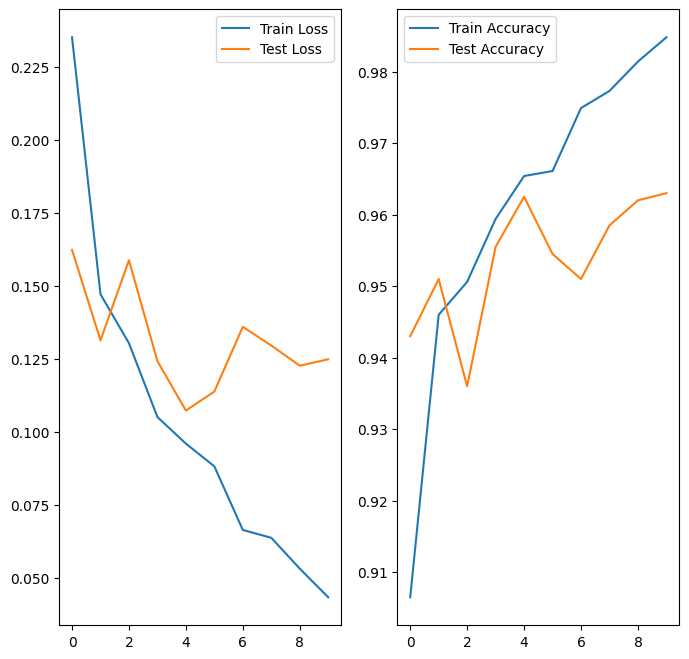

In [ ]:
plot_curves(train_accs, train_losses, test_accs, test_losses)

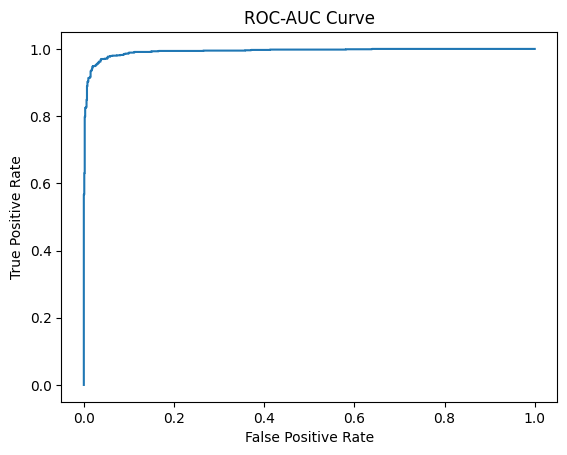

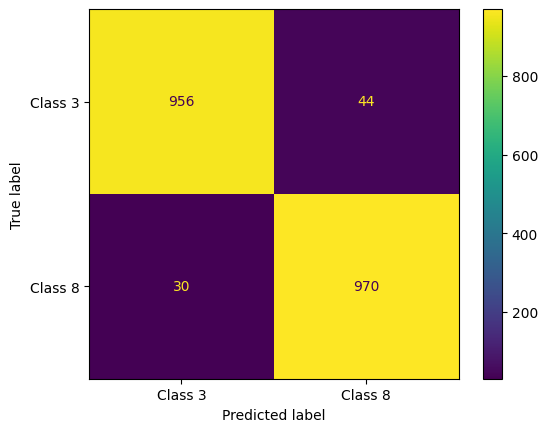

Accuracy:0.9629999995231628, F1-Score: 0.9632571935653687, AUC: 0.9929470419883728


In [ ]:
no_reg_acc, no_reg_f1, no_reg_auc =performance_metrics(model_no_regularizaton,test_loader)

In [ ]:
# training model with regularization, dropout of 0.45
model_with_reg = CoolCNN(dropout_rate=0.45)

train_accs, train_losses, test_accs, test_losses  = train(model_with_reg, train_loader, test_loader, epochs, learning_rate)

Epoch: 0/10, Train Loss: 0.25168729758566355, Train Accuracy: 0.8934
Epoch: 0/10, Test Loss: 0.18675121432170272, Test Accuracy: 0.92
Epoch: 1/10, Train Loss: 0.155818171727999, Train Accuracy: 0.9387
Epoch: 1/10, Test Loss: 0.1293930287938565, Test Accuracy: 0.9545
Epoch: 2/10, Train Loss: 0.12569350007755362, Train Accuracy: 0.9526
Epoch: 2/10, Test Loss: 0.12026397872250527, Test Accuracy: 0.9545
Epoch: 3/10, Train Loss: 0.10842110463388406, Train Accuracy: 0.9604
Epoch: 3/10, Test Loss: 0.11612048771348782, Test Accuracy: 0.955
Epoch: 4/10, Train Loss: 0.10016722042872837, Train Accuracy: 0.9622
Epoch: 4/10, Test Loss: 0.1221306340303272, Test Accuracy: 0.9545
Epoch: 5/10, Train Loss: 0.07795222350366555, Train Accuracy: 0.9694
Epoch: 5/10, Test Loss: 0.11456144554540515, Test Accuracy: 0.96
Epoch: 6/10, Train Loss: 0.06767809463985217, Train Accuracy: 0.9761
Epoch: 6/10, Test Loss: 0.10631555737927556, Test Accuracy: 0.9595
Epoch: 7/10, Train Loss: 0.06350302556233042, Train Accur

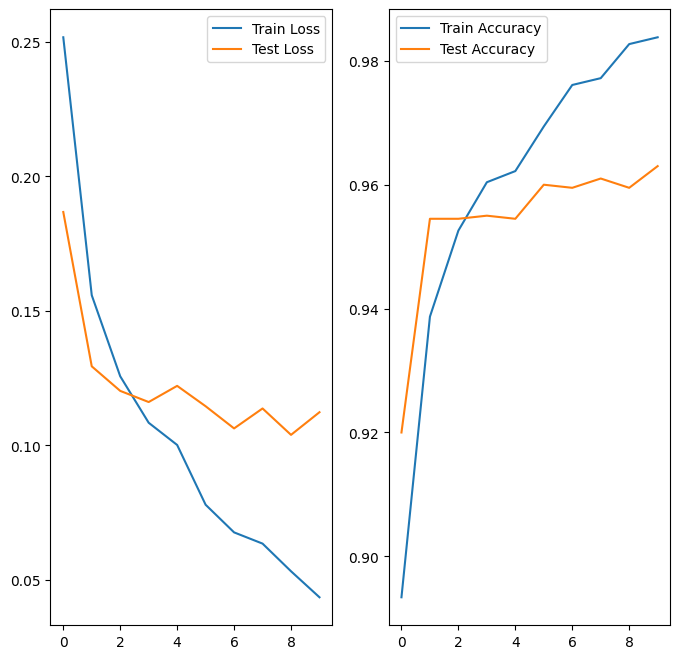

In [ ]:
plot_curves(train_accs, train_losses, test_accs, test_losses)

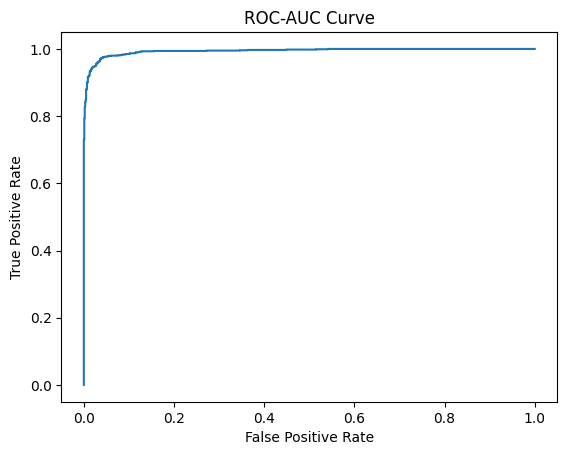

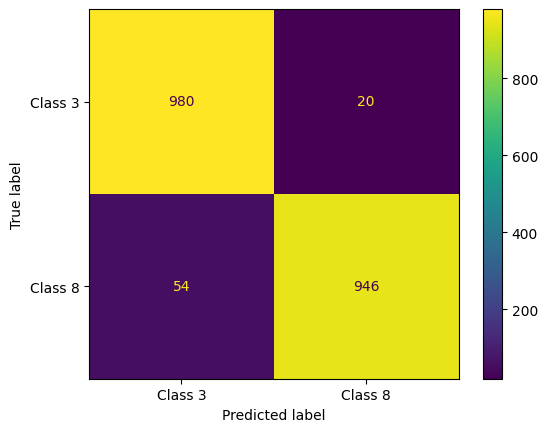

Accuracy:0.9629999995231628, F1-Score: 0.962360143661499, AUC: 0.9937489628791809


In [ ]:
with_reg_acc, with_reg_f1, with_reg_auc = performance_metrics(model_with_reg,test_loader)

# Regularization vs No Regularization Comparison

In [ ]:
import pandas as pd


cool_cnn_data = {
    'Accuracy': [f"{float(no_reg_acc):.4f}", f"{float(with_reg_acc):.4f}"],
    'F1-Score': [f"{float(no_reg_f1):.4f}", f"{float(with_reg_f1):.4f}"],
    'AUC': [f"{float(no_reg_auc):.4f}", f"{float(with_reg_auc):.4f}"],
    'Regularization': ['No Regularization', 'With Regularization']
}

df = pd.DataFrame(cool_cnn_data)
df


,Accuracy,F1-Score,AUC,Regularization
0,0.9630,0.9633,0.9929,No Regularization
1,0.9630,0.9624,0.9937,With Regularization


# Part II Linear Probing

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18 , ResNet18_Weights
def init_resnet18():
  weights = ResNet18_Weights.DEFAULT
  model = resnet18(weights=weights)
  for param in model.parameters():
    param.requires_grad = False

  in_features = model.fc.in_features
  model.fc = nn.Linear(in_features,2)

  return model

In [ ]:
model_part_2 =  init_resnet18()

train_accs, train_losses, test_accs, test_losses  = train(model_part_2, train_loader, test_loader, epochs, learning_rate)

Epoch: 0/10, Train Loss: 0.4347983462036036, Train Accuracy: 0.8008
Epoch: 0/10, Test Loss: 0.3595069469884038, Test Accuracy: 0.8595
Epoch: 1/10, Train Loss: 0.33660359889458696, Train Accuracy: 0.8582
Epoch: 1/10, Test Loss: 0.3510708948597312, Test Accuracy: 0.8525
Epoch: 2/10, Train Loss: 0.32539184856566655, Train Accuracy: 0.8641
Epoch: 2/10, Test Loss: 0.35408158181235194, Test Accuracy: 0.845
Epoch: 3/10, Train Loss: 0.3274896300522385, Train Accuracy: 0.8619
Epoch: 3/10, Test Loss: 0.3395663844421506, Test Accuracy: 0.8645
Epoch: 4/10, Train Loss: 0.3266349082729619, Train Accuracy: 0.8574
Epoch: 4/10, Test Loss: 0.3431087927892804, Test Accuracy: 0.8655
Epoch: 5/10, Train Loss: 0.3192118784994077, Train Accuracy: 0.8642
Epoch: 5/10, Test Loss: 0.3283433811739087, Test Accuracy: 0.8705
Epoch: 6/10, Train Loss: 0.313344913588208, Train Accuracy: 0.8698
Epoch: 6/10, Test Loss: 0.33438814943656325, Test Accuracy: 0.871
Epoch: 7/10, Train Loss: 0.30435873017569254, Train Accuracy:

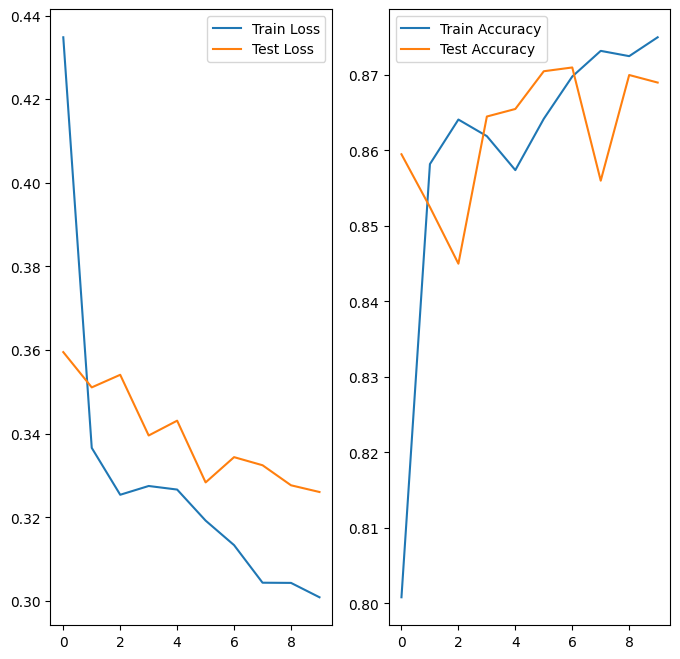

In [ ]:
plot_curves(train_accs, train_losses, test_accs, test_losses)

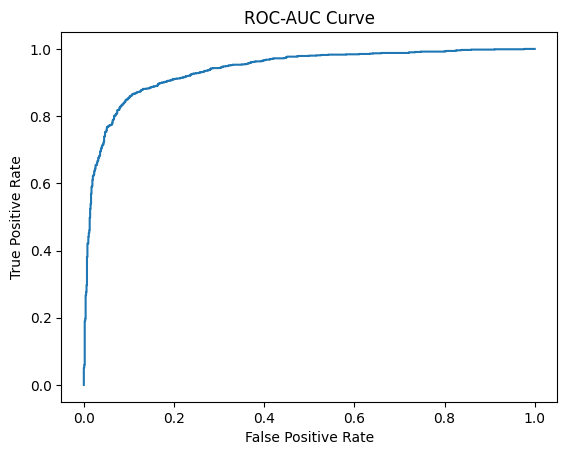

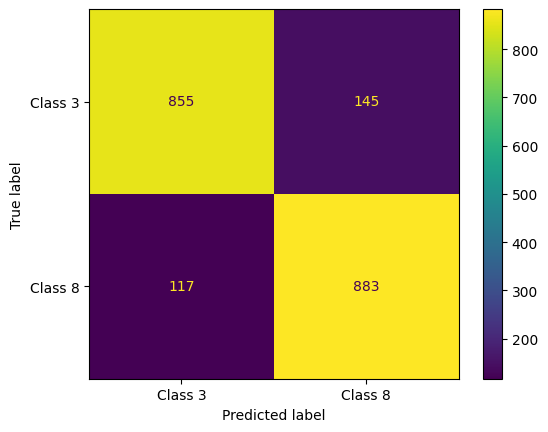

Accuracy:0.8690000176429749, F1-Score: 0.8708086609840393, AUC: 0.9387380480766296


In [ ]:
linear_probing_acc, linear_probing_f1, linear_probing_auc = performance_metrics(model_part_2,test_loader)

Linear Probing Performance

In [ ]:
linear_probing_data = {
    'Accuracy': [f"{float(linear_probing_acc):.3f}"],
    'F1-Score': [f"{float(linear_probing_f1):.3f}"],
    'AUC': [f"{float(linear_probing_auc):.3f}"],
}

df = pd.DataFrame(linear_probing_data)
df

,Accuracy,F1-Score,AUC
0,0.869,0.871,0.939


In [ ]:
model_grayscale =  init_resnet18()

train_accs, train_losses, test_accs, test_losses  = train(model_grayscale, train_loader_grayscale, test_loader_grayscale, epochs, learning_rate)

Epoch: 0/10, Train Loss: 0.5069147044685995, Train Accuracy: 0.7576
Epoch: 0/10, Test Loss: 0.4230063911527395, Test Accuracy: 0.814
Epoch: 1/10, Train Loss: 0.4195172657632524, Train Accuracy: 0.8152
Epoch: 1/10, Test Loss: 0.4237587694078684, Test Accuracy: 0.8105
Epoch: 2/10, Train Loss: 0.3984717087950676, Train Accuracy: 0.8288
Epoch: 2/10, Test Loss: 0.402713593095541, Test Accuracy: 0.8165
Epoch: 3/10, Train Loss: 0.39339550817088714, Train Accuracy: 0.8281
Epoch: 3/10, Test Loss: 0.39688288513571024, Test Accuracy: 0.822
Epoch: 4/10, Train Loss: 0.3899849134076173, Train Accuracy: 0.8321
Epoch: 4/10, Test Loss: 0.37874256540089846, Test Accuracy: 0.8355
Epoch: 5/10, Train Loss: 0.3922323452629102, Train Accuracy: 0.8279
Epoch: 5/10, Test Loss: 0.3913743197917938, Test Accuracy: 0.829
Epoch: 6/10, Train Loss: 0.38354683207098844, Train Accuracy: 0.8263
Epoch: 6/10, Test Loss: 0.37891711201518774, Test Accuracy: 0.8325
Epoch: 7/10, Train Loss: 0.3826919188545008, Train Accuracy: 

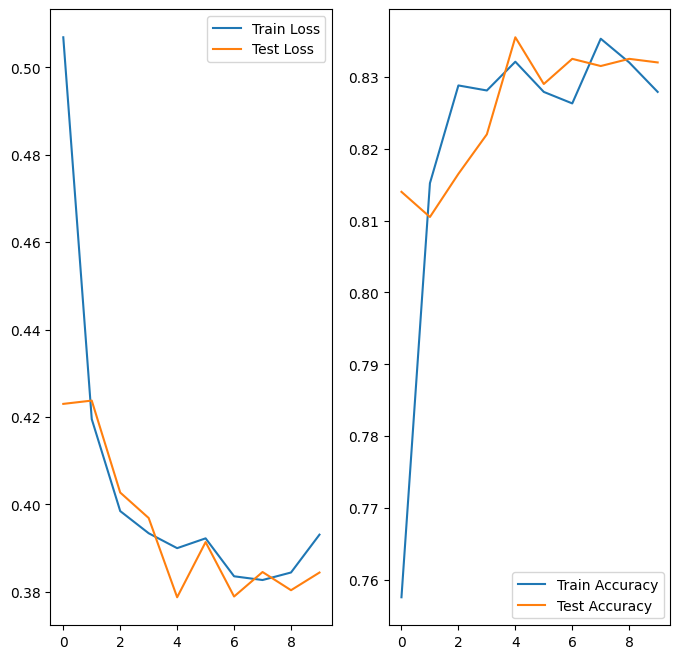

In [ ]:
plot_curves(train_accs, train_losses, test_accs, test_losses)

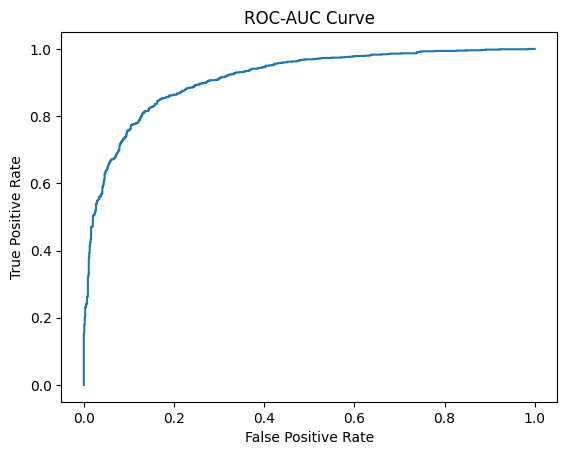

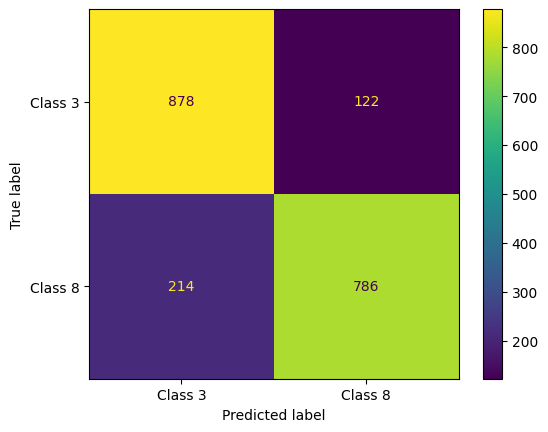

Accuracy:0.8320000171661377, F1-Score: 0.8238993883132935, AUC: 0.9127509593963623


In [ ]:
 linear_prob_gray_acc,  linear_prob_gray_f1,linear_prob_gray_auc = performance_metrics(model_grayscale,test_loader_grayscale)

In [ ]:
linear_probing_compared = {
    'Accuracy': [f"{float(linear_probing_acc):.3f}", f"{float(linear_prob_gray_acc):.3f}"],
    'F1-Score': [f"{float(linear_probing_f1):.3f}", f"{float(linear_prob_gray_f1):.3f}"],
    'AUC': [f"{float(linear_probing_auc):.3f}", f"{float(linear_prob_gray_auc):.3f}"],
    'Dataset': ['Color', 'Grayscale']
}

df = pd.DataFrame(linear_probing_compared)
df

,Accuracy,F1-Score,AUC,Dataset
0,0.869,0.871,0.939,Color
1,0.832,0.824,0.913,Grayscale
